In [44]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

import pickle



### Carga de datos

In [45]:
df_adult = pd.read_csv("../data/raw/13_adult.csv")
df_adult.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [46]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [47]:
df_adult.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


##### Limpieza básica

Encontramos a simple vista datos con "?", asi que vamos a hacer una limpieza de datos nulos o mal codificados.

In [48]:
df_adult = df_adult.applymap(lambda x: x.strip() if isinstance(x, str) else x) #quitar espacios
df_adult.replace("?", pd.NA, inplace=True)# "?" --> Nan
df_adult.dropna(inplace=True)# quitar filas con nulos

df_adult.head()

/tmp/ipykernel_746/2263759367.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_adult = df_adult.applymap(lambda x: x.strip() if isinstance(x, str) else x) #quitar espacios


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


Comprobamos que nuestra variable `income` este correcta para el modelo y creamos nuestra variable objetivo con ella.

In [49]:
df_adult["income"].unique()
df_adult["high_income"] = (df_adult["income"] == ">50K").astype(int)
#eliminar "income"
df_adult.drop(columns=["income"], inplace=True)
df_adult.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,high_income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,0
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,0


#### Visualización
Vamos a realizar una visualización de las variables que pueden ser más representativas para el nivel de ingresos, como por ejemplo la educación y/o las horas de trabajo.

##### Educación vs nivel de ingresos

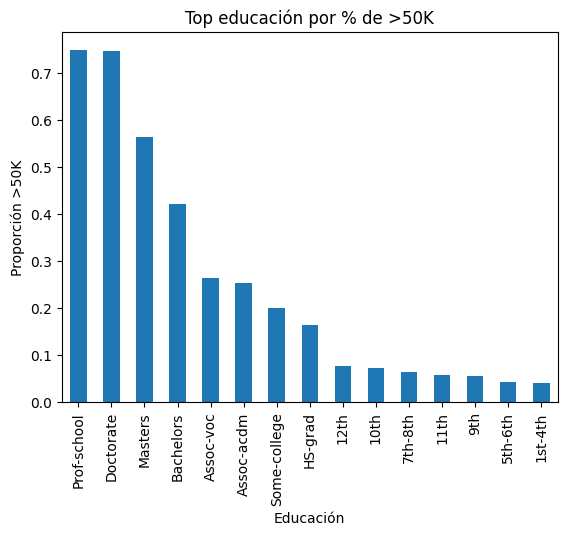

In [50]:
edu_rate = df_adult.groupby("education")["high_income"].mean().sort_values(ascending=False).head(15)

plt.figure()
edu_rate.plot(kind="bar")
plt.title("Top educación por % de >50K")
plt.xlabel("Educación")
plt.ylabel("Proporción >50K")
plt.show()


Se ve que, en general, a mayor nivel educativo, mayor proporción de personas que superan 50K.

##### Horas por semana vs nivel de ingresos

/tmp/ipykernel_746/1610128840.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_adult.groupby("hours_bin")["high_income"].mean()


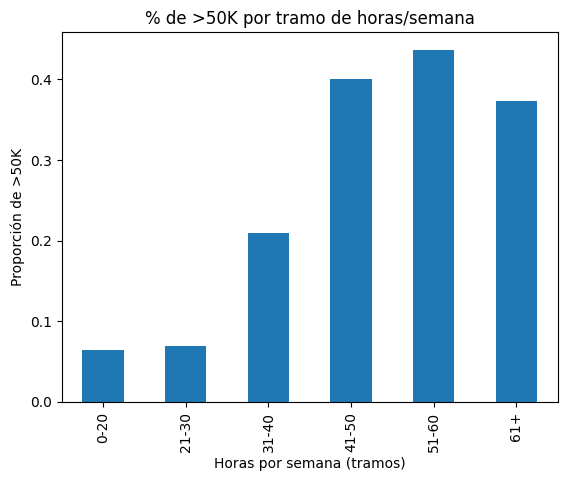

In [51]:
#creamos tramos de horas (bins)
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ["0-20", "21-30", "31-40", "41-50", "51-60", "61+"]

df_adult["hours_bin"] = pd.cut(df_adult["hours.per.week"], bins=bins, labels=labels, right=True, include_lowest=True)

rate = df_adult.groupby("hours_bin")["high_income"].mean()

plt.figure()
rate.plot(kind="bar")
plt.title("% de >50K por tramo de horas/semana")
plt.xlabel("Horas por semana (tramos)")
plt.ylabel("Proporción de >50K")
plt.show()


La proporción de >50K sube bastante a partir de 40 horas/semana, así que esta variable puede ser útil para el modelo y para simular cambios

#### Preprocesamiento
Transformar categóricas, normalizar numéricas.

In [52]:
features = ["age", "education", "marital.status", "occupation",
            "hours.per.week", "sex", "native.country"]

X = df_adult[features]
y = df_adult["high_income"]

numeric_features = ["age", "hours.per.week"]
categorical_features = ["education", "marital.status", "occupation", "sex", "native.country"]

prepro = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_features),
                                         ("cat", OneHotEncoder(handle_unknown="ignore"),categorical_features)])


#### Modelo regresión logística

In [53]:
model = Pipeline(steps=[("preprocessor", prepro),
                        ("classifier", LogisticRegression(max_iter=1000))])#aplicar el mismo preprocesado en train, test y usuarios nuevo

##### Train/test split y fit

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Evaluación

In [55]:
proba_test = model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

accuracy_score(y_test, pred_test)

0.836399801093983

In [56]:
roc_auc_score(y_test, proba_test)

0.8915279149613213

El modelo acierta ~0.84 en el conjunto de test. El ROC AUC (~0.89) sugiere que separa bastante bien las clases (>50K vs <=50K), 

#### Definir problema de recomendación

Ahora vamos a probar el modelo para estimar la probabilidad de que una persona gane mas de 50k según su perfil. Como recomendador simple, probamos 2 cambios de educación y 1 cambio de horas para ver cómo varía la probabilidad.

In [57]:
def recommend(user_profile):
    #pasamos dict a df
    user_df = pd.DataFrame([user_profile])

    #predicción: 1 = >50K, 0 = <=50K
    pred = model.predict(user_df)[0]
    #probabilidad de la clase 1
    prob = model.predict_proba(user_df)[0][1]

    #mensaje según si sale alta o baja
    if pred == 1:
        msg = "OK: perfil con probabilidad alta de >50K"
    else:
        msg = "Baja probabilidad: probamos cambios "

    #primera fila: resultado original 
    rows = [{"tipo": "BASE",
             "cambio": "-",
             "prediccion": int(pred),
             "proba_>50K_%": round(prob * 100, 1),
             "mensaje": msg}]

    #2 cambios de education
    top_edus = df_adult["education"].value_counts().head(2).index.tolist()

    for edu in top_edus:        
        cand = dict(user_profile)
        cand["education"] = edu
        #nueva probabilidad
        p = model.predict_proba(pd.DataFrame([cand]))[0][1]
        #guardamos nueva fila
        rows.append({"tipo": "Escenario",
                     "cambio":  f"education -> {edu}",
                     "prediccion": "",#solo probabilidad
                     "proba_>50K_%": round(p * 100, 1),
                     "mensaje": ""})
        
    #1 cambio de horas
    cand = dict(user_profile)
    cand["hours.per.week"] = 40
    p = model.predict_proba(pd.DataFrame([cand]))[0][1]

    rows.append({"tipo": "Escenario",
                 "cambio": "hours.per.week -> 40",
                 "prediccion": "",
                 "proba_>50K_%": round(p * 100, 1),
                 "mensaje": ""})
    
    return pd.DataFrame(rows)


In [58]:
simulated_user = {"age": 25,
                  "education": "HS-grad",
                  "marital.status": "Never-married",
                  "occupation": "Sales",
                  "hours.per.week": 30,
                  "sex": "Male",
                  "native.country": "United-States"}

simulated_user_2 = {"age": 40,
                    "education": "Bachelors",
                    "marital.status": "Married-civ-spouse",
                    "occupation": "Tech-support",
                    "hours.per.week": 40,
                    "sex": "Female",
                    "native.country": "United-States"}

recommend(simulated_user)


,tipo,cambio,prediccion,proba_>50K_%,mensaje
0,BASE,-,0,2.0,Baja probabilidad: probamos cambios
1,Escenario,education -> HS-grad,,2.0,
2,Escenario,education -> Some-college,,2.8,
3,Escenario,hours.per.week -> 40,,2.7,


#### Guardado del modelo

In [61]:
with open("../models/adult_income_regresión_logistica.pkl", "wb") as f:
    pickle.dump(model, f)

### Conclusión

En este modelo hemos entrenado un modelo de regresión logística para predecir si una persona gana más de 50k. El modelo obtiene una accuracy de 84% y un ROC-AUC de 89%, con estos datos hemos probado un sistema recomendador muy simple simulandocambios en educación y en horas por semana para ver como varía la probabilidad calculada por el modelo.